# 2D Bayesian RL Environment Quickstart
This notebook provides a minimal starting point for experiments with the 100x100 grid environment.

In [11]:
from pathlib import Path
import matplotlib.pyplot as plt
import sys
import numpy as np


# Ensure project root (parent of notebooks/) is on PYTHONPATH
project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Import directly from module (not from src/__init__.py)
from src.environment_2 import ProbabilisticSimpleSystem

env = ProbabilisticSimpleSystem(seed=64)

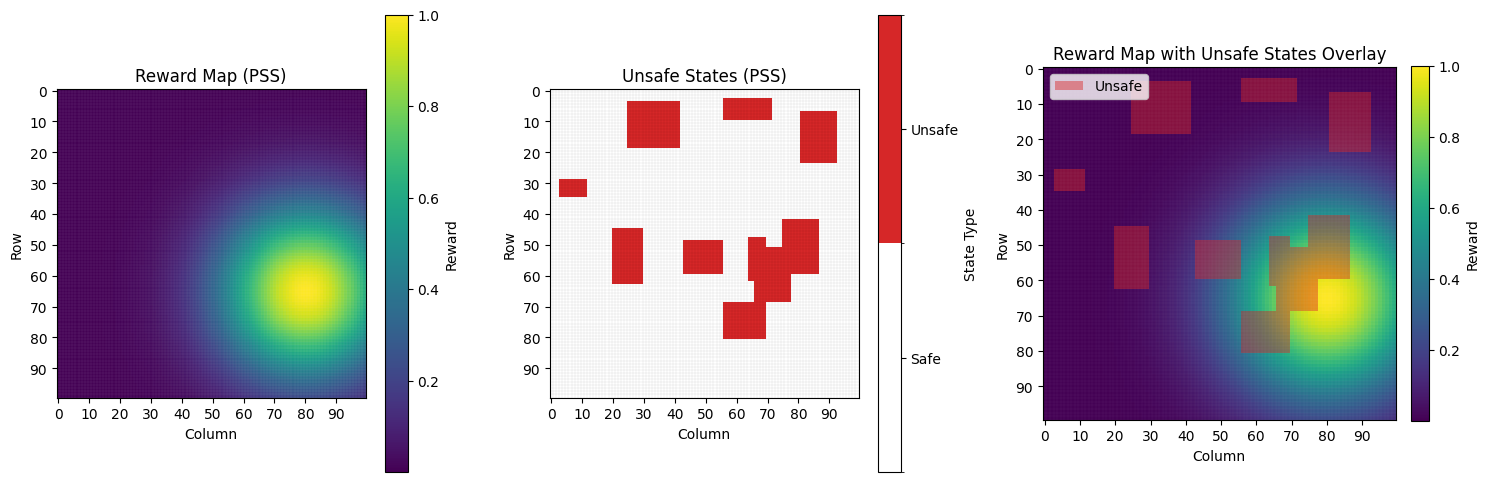

In [12]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
env.plot_reward_map(ax=axs[0])
env.plot_unsafe_mask(ax=axs[1])
env.plot_combined(ax=axs[2])
plt.tight_layout()


## Transition Function Visualization
Sample the transition function many times and visualize where we end up.

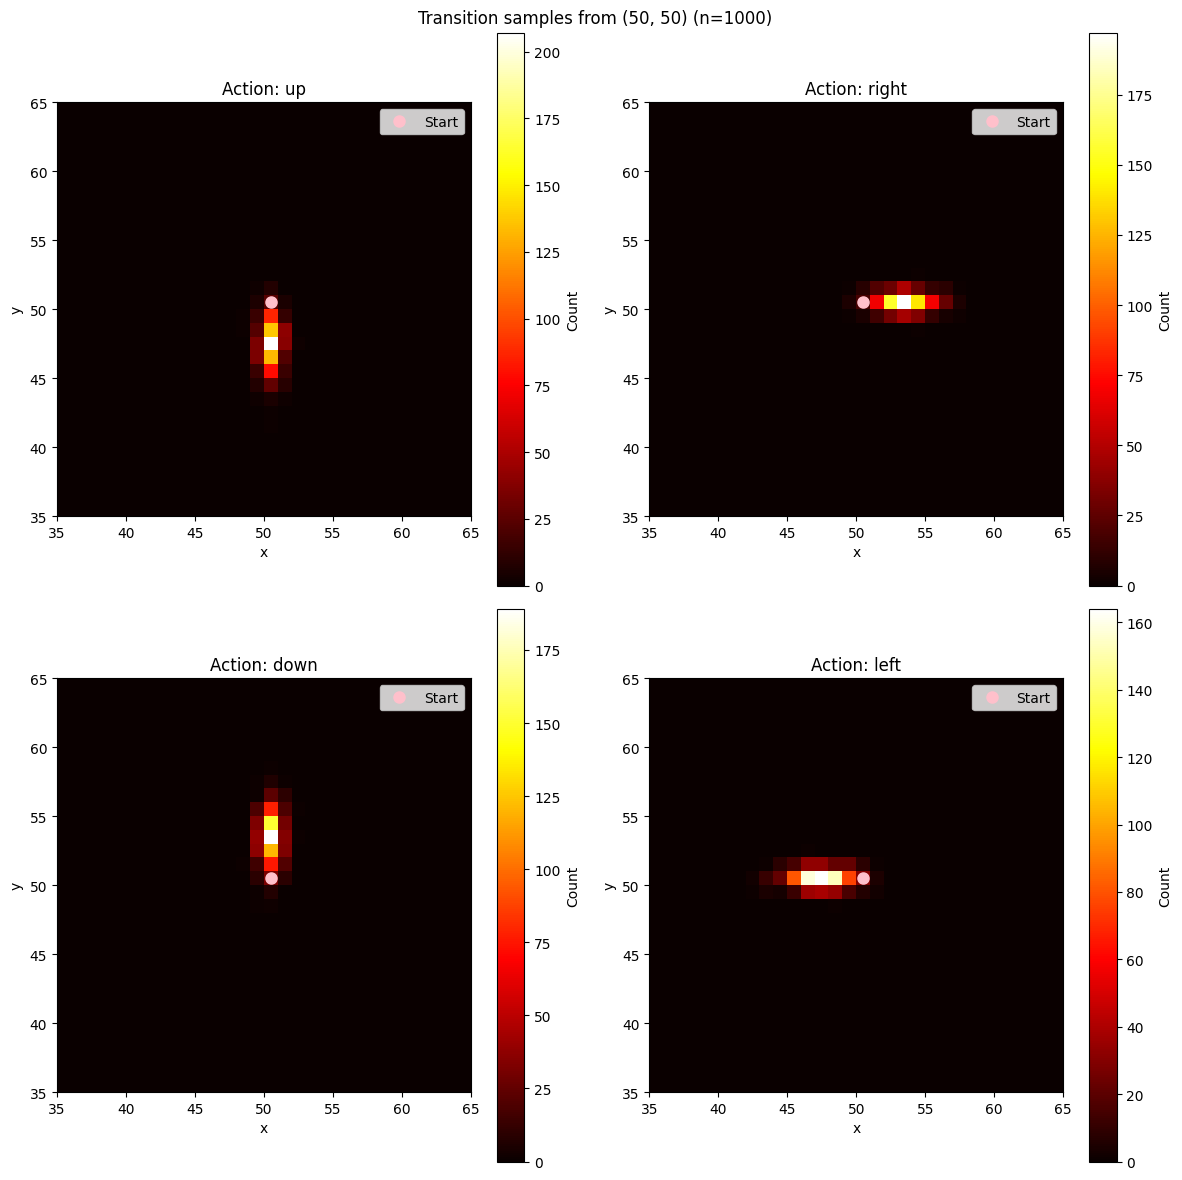

In [ ]:
# Sample transition function many times and count outcomes
start_state = (50, 50)
n_samples = 1000

# Actions: [up, right, down, left]
actions = {
    'up': (0, -1),
    'right': (1, 0),
    'down': (0, 1),
    'left': (-1, 0),
}

fig, axs = plt.subplots(2, 2, figsize=(12, 12))
axs = axs.flatten()

for ax, (action_name, action) in zip(axs, actions.items()):
    # Count where we end up
    counts = np.zeros((100, 100))
    for _ in range(n_samples):
        x, y = env.transition(start_state, action)
        counts[y, x] += 1
    
    zoom = 15
    x0, y0 = start_state
    x_min, x_max = max(0, x0 - zoom), min(100, x0 + zoom)
    y_min, y_max = max(0, y0 - zoom), min(100, y0 + zoom)
    
    zoomed = counts[y_min:y_max, x_min:x_max]
    
    im = ax.imshow(zoomed, cmap='hot', origin='lower', 
                   extent=[x_min, x_max, y_min, y_max])
    ax.plot(x0 + 0.5, y0 + 0.5, 'o', markersize=8, label='Start', color='pink')
    ax.set_title(f"Action: {action_name}")
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend()
    plt.colorbar(im, ax=ax, label='Count')

plt.suptitle(f'Transition samples from {start_state} (n={n_samples})')
plt.tight_layout()

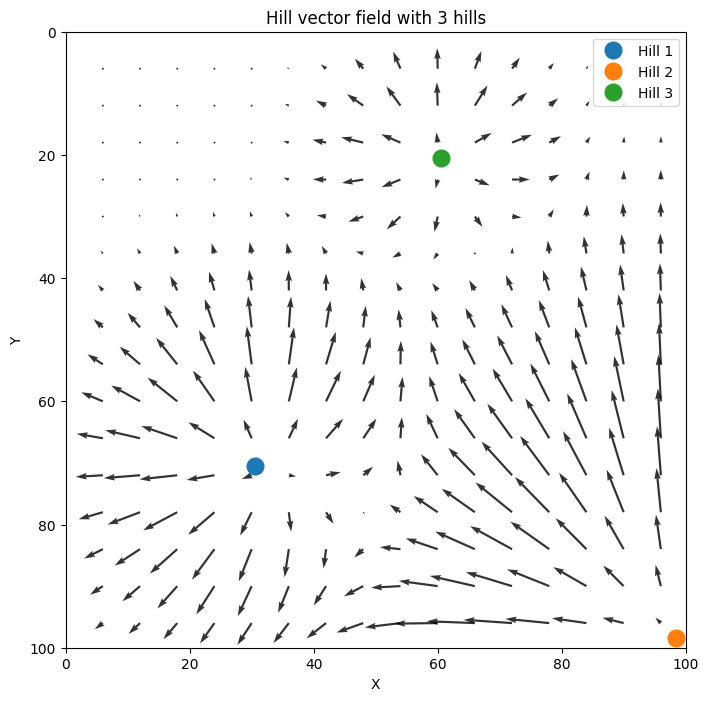

In [14]:
env.clear_hills()
env.add_hill(top=(30, 70), sigma=15.0, strength=35, normalized=False)
env.add_hill(top=(98, 98), sigma=30.0, strength=100, normalized=False)
env.add_hill(top=(60, 20), sigma = 10, strength=15.0, normalized=False)

env.plot_hills()
plt.title("Hill vector field with 3 hills")
plt.show()

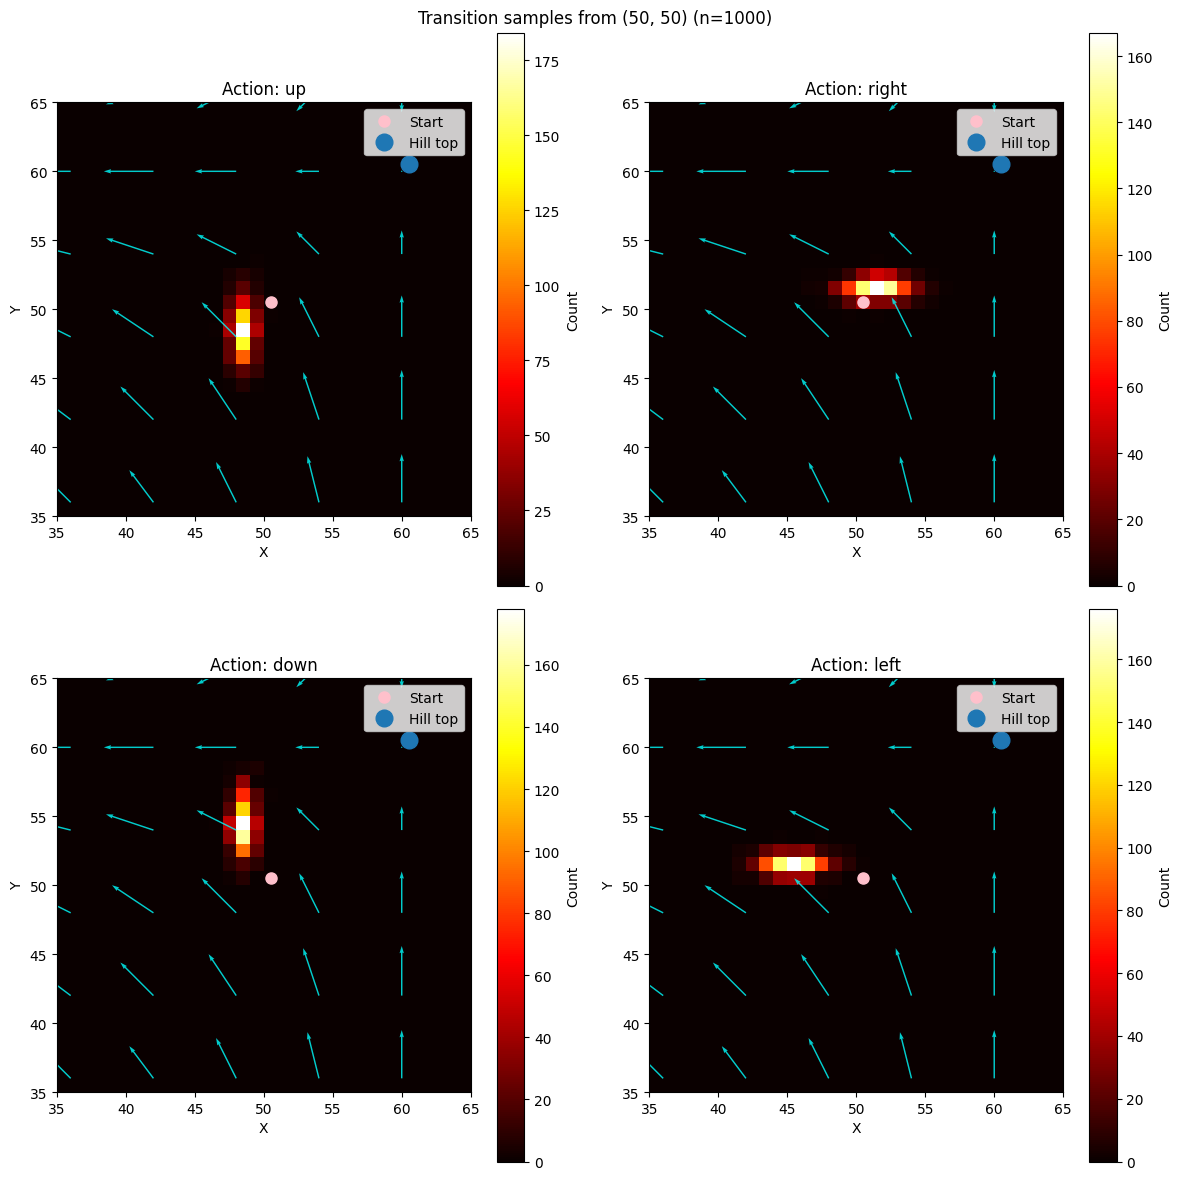

In [15]:
env.clear_hills()
env.add_hill(top=(60, 60), sigma=20.0, strength=100.0, normalized=False)

fig, axs = plt.subplots(2, 2, figsize=(12, 12))
axs = axs.flatten()

for ax, (action_name, action) in zip(axs, actions.items()):
    # Count where we end up
    counts = np.zeros((100, 100))
    for _ in range(n_samples):
        x, y = env.transition(start_state, action)
        counts[y, x] += 1
    
    zoom = 15
    x0, y0 = start_state
    x_min, x_max = max(0, x0 - zoom), min(100, x0 + zoom)
    y_min, y_max = max(0, y0 - zoom), min(100, y0 + zoom)
    
    zoomed = counts[y_min:y_max, x_min:x_max]
    
    im = ax.imshow(zoomed, cmap='hot', origin='lower', 
                   extent=[x_min, x_max, y_min, y_max])
    ax.plot(x0 + 0.5, y0 + 0.5, 'o', markersize=8, label='Start', color='pink')
    ax.set_title(f"Action: {action_name}")
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend()
    plt.colorbar(im, ax=ax, label='Count')
    env.plot_hills(color='cyan', ax=ax)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

plt.suptitle(f'Transition samples from {start_state} (n={n_samples})')
plt.tight_layout()

